In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils

# Reading chains

In [3]:
# No compression
s_2pt = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-no-compression/des-y3-2pt-blind-metacal.txt', to_mcsamples=True)
s_map3 = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-no-compression/des-y3-map3-blind-metacal.txt', to_mcsamples=True)

Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in


<Figure size 600x600 with 0 Axes>

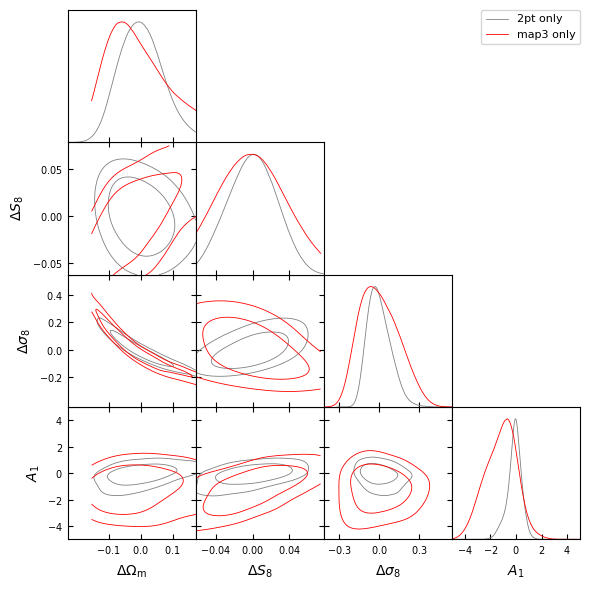

In [5]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_2pt, s_map3], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt only', 'map3 only'], legend_loc='upper right', 
    contour_colors=['gray', 'red'])
plt.show()

<Figure size 600x600 with 0 Axes>

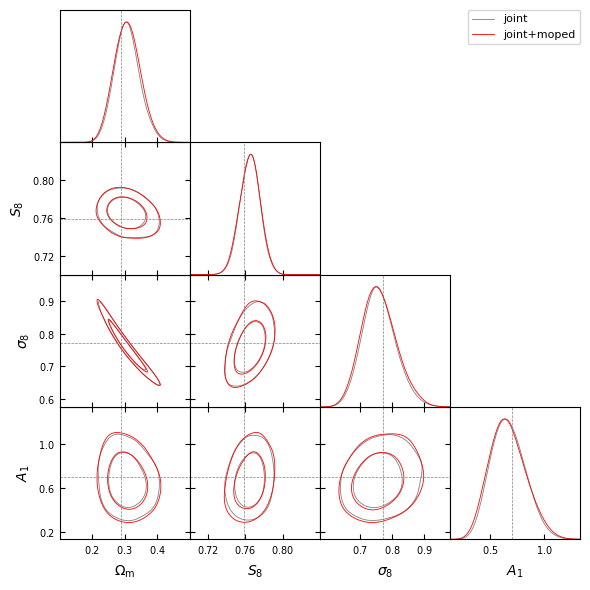

In [7]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_joint_auto, s_joint_moped_auto], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['joint', 'joint+moped'], legend_loc='upper right', 
    contour_colors=['gray', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

<Figure size 600x600 with 0 Axes>

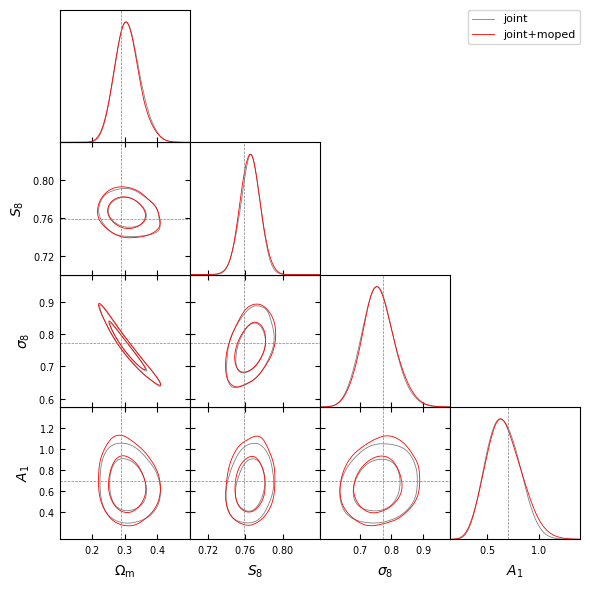

In [8]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_joint_auto_334_344, s_joint_moped_auto_334_344], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['joint', 'joint+moped'], legend_loc='upper right', 
    contour_colors=['gray', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

## What if not include cross-covariance?

<Figure size 600x600 with 0 Axes>

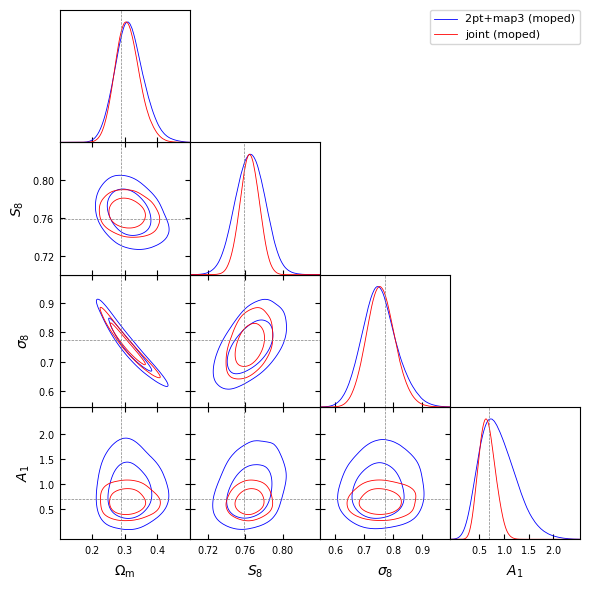

In [10]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_2pt_map3_moped, s_joint_moped], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt+map3 (moped)', 'joint (moped)'], legend_loc='upper right', 
    contour_colors=['blue', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

## Gain

<Figure size 1000x1000 with 0 Axes>

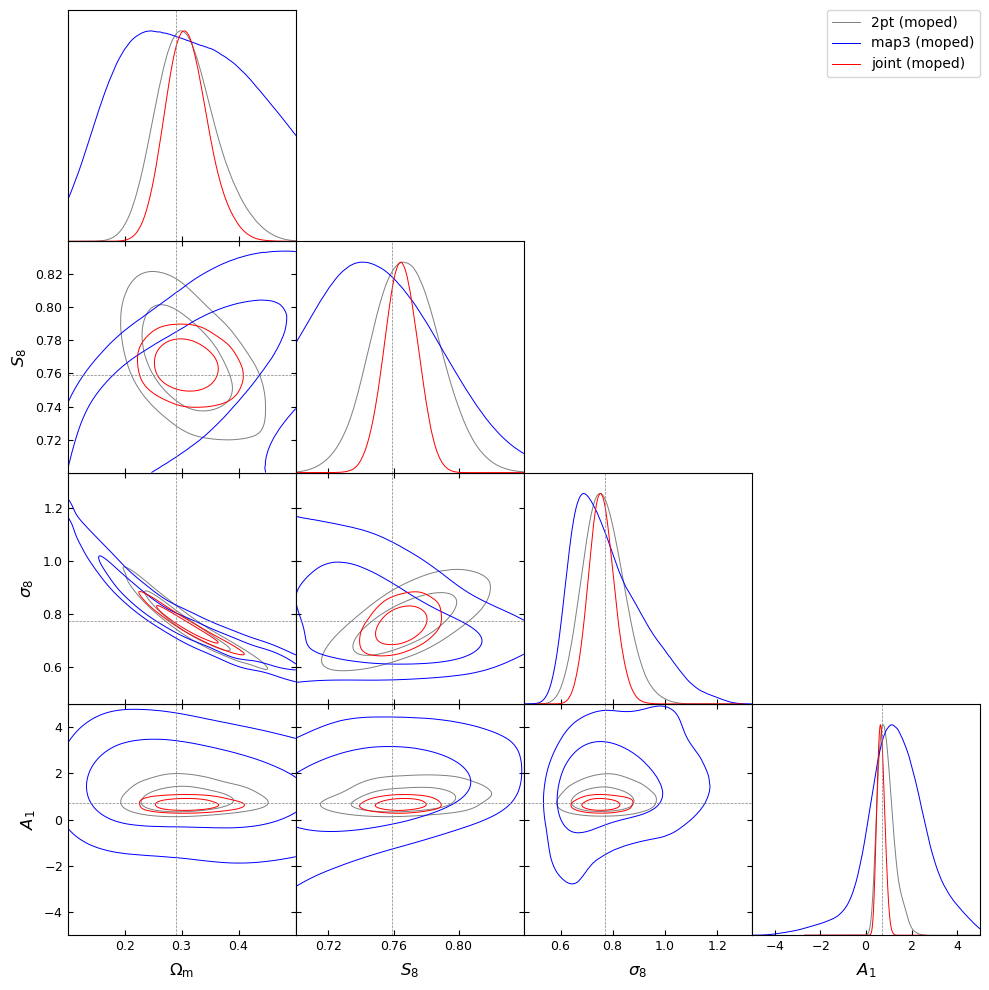

In [18]:
g = plots.get_single_plotter(ratio=1, width_inch=10)
g.triangle_plot([s_2pt_moped, s_map3_moped, s_joint_moped], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt (moped)', 'map3 (moped)', 'joint (moped)'], legend_loc='upper right', 
    contour_colors=['gray', 'blue', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

In [16]:
fom_2pt_moped = utils.FoM_from_samples_names(s_2pt_moped, ['s8', 'om'])
fom_joint_moped = utils.FoM_from_samples_names(s_joint_moped, ['s8','om'])

print('fom of 2pt:', fom_2pt_moped)
print('fom of joint+moped:', fom_joint_moped)
print('fom gain:', fom_joint_moped/fom_2pt_moped)

fom of 2pt: 1094.2313997327801
fom of joint+moped: 2629.4172594430725
fom gain: 2.4029809966019955


<Figure size 800x800 with 0 Axes>

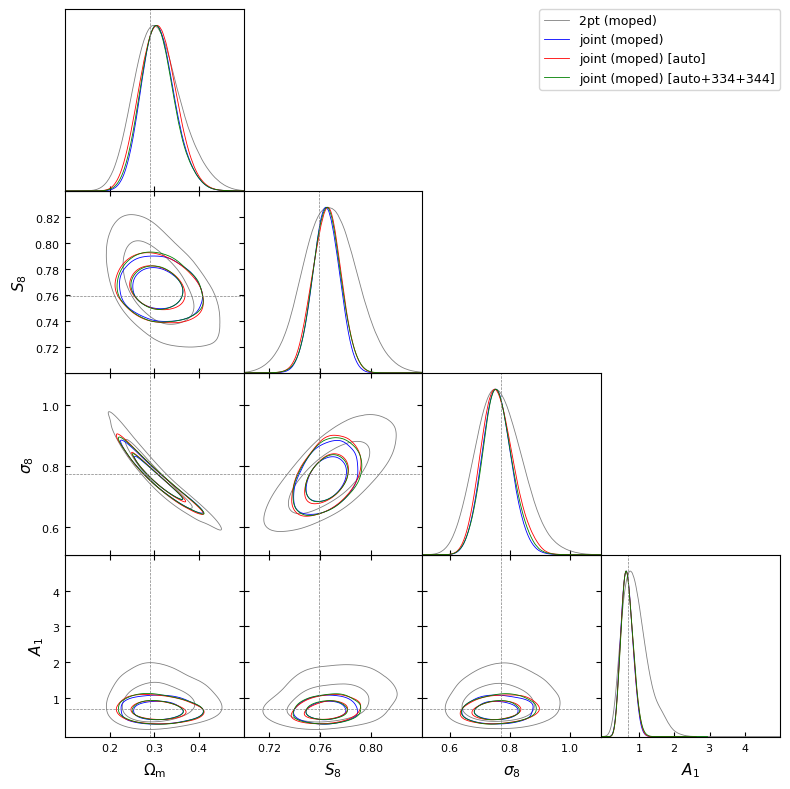

In [24]:
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([s_2pt_moped, s_joint_moped, s_joint_moped_auto, s_joint_moped_auto_334_344], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt (moped)', 'joint (moped)', 'joint (moped) [auto]', 'joint (moped) [auto+334+344]'], legend_loc='upper right', 
    contour_colors=['gray', 'blue', 'red', 'green', 'k'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

In [28]:
fom_2pt_moped = utils.FoM_from_samples_names(s_2pt_moped, ['s8', 'om'])
fom_joint_moped = utils.FoM_from_samples_names(s_joint_moped, ['s8','om'])
fom_joint_moped_auto = utils.FoM_from_samples_names(s_joint_moped_auto, ['s8','om'])
fom_joint_moped_auto_334_344 = utils.FoM_from_samples_names(s_joint_moped_auto_334_344, ['s8','om'])

print('fom of 2pt:', fom_2pt_moped)
print('fom of joint (auto):', fom_joint_moped_auto)
print('fom of joint (auto+334+344):', fom_joint_moped_auto_334_344)
print('fom of joint (all)', fom_joint_moped)
print('fom gain (all):', fom_joint_moped_auto/fom_2pt_moped)
print('fom gain (auto):', fom_joint_moped_auto_334_344/fom_2pt_moped)
print('fom gain (auto+334+344):', fom_joint_moped/fom_2pt_moped)

fom of 2pt: 1094.2313997327801
fom of joint (auto): 2317.8437144402938
fom of joint (auto+334+344): 2449.3583411562445
fom of joint (all) 2629.4172594430725
fom gain (all): 2.1182390808802682
fom gain (auto): 2.2384281256728666
fom gain (auto+334+344): 2.4029809966019955


/Users/sugiyamasunao/miniconda3/envs/csis3pcf/lib/python3.11/site-packages/getdist/plots.py:1962: UserWarning: Legend does not support handles for NoneType instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  self.legend = self.fig.legend(lines, legend_labels, loc=legend_loc, **args)


<Figure size 800x800 with 0 Axes>

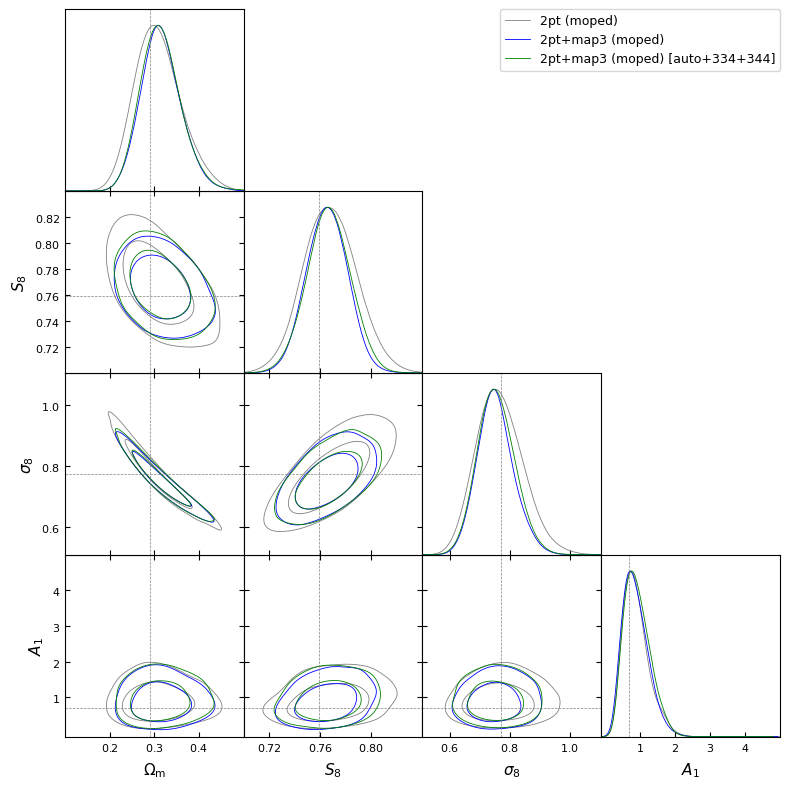

In [25]:
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([s_2pt_moped, s_2pt_map3_moped, s_2pt_map3_moped_auto, s_2pt_map3_moped_auto_334_344], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt (moped)', '2pt+map3 (moped)', '2pt+map3 (moped) [auto]', '2pt+map3 (moped) [auto+334+344]'], legend_loc='upper right', 
    contour_colors=['gray', 'blue', 'red', 'green', 'k'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

---------------

## Where does IA constraning power comes from?

<Figure size 800x800 with 0 Axes>

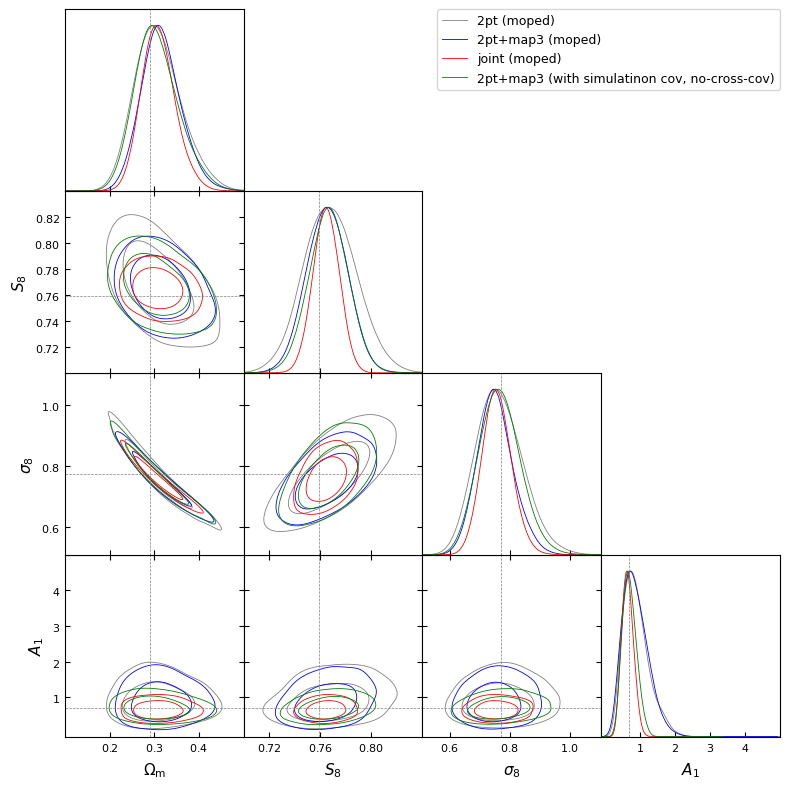

In [31]:
# Comparing "s_2pt_map3_moped" and "s_joint_no_cross" chains.
# Here the only difference is the 2pt covariance
# former = analytic covariance
# latter = simulation-based covariance (Hartlap is included properly)
#
# This makes such a big difference????!!!!
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([s_2pt_moped, s_2pt_map3_moped, s_joint_moped, s_joint_no_cross], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt (moped)', '2pt+map3 (moped)', 'joint (moped)', '2pt+map3 (with simulatinon cov, no-cross-cov)'], legend_loc='upper right', 
    contour_colors=['gray', 'blue', 'red', 'green'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()